<a href="https://colab.research.google.com/github/andrew4514/DSAI/blob/main/Klasifikasi_Kualitas_Tidur.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data Preprocessing**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from numpy import arange
df = pd.read_csv("dataset_raw.csv", keep_default_na=False)
df.head()


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


### Menghapus Kolom (Person ID)

In [ ]:
df_clean = df.drop(columns=["Person ID"])
df_clean.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None
1,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
3,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


### Standarisasi Kolom BMI Category

In [ ]:
print("Sebelum standardisasi:")
print(df_clean["BMI Category"].value_counts())

df_clean["BMI Category"] = df_clean["BMI Category"].replace({"Normal Weight": "Normal"})

print("\nSetelah standardisasi:")
print(df_clean["BMI Category"].value_counts())

Sebelum standardisasi:
BMI Category
Normal           195
Overweight       148
Normal Weight     21
Obese             10
Name: count, dtype: int64

Setelah standardisasi:
BMI Category
Normal        216
Overweight    148
Obese          10
Name: count, dtype: int64


### Pecah kolom Blood Pressure

In [ ]:
bp_split = df_clean["Blood Pressure"].str.split("/", expand=True)
df_clean["Systolic_BP"] = bp_split[0].astype(int)
df_clean["Diastolic_BP"] = bp_split[1].astype(int)

df_clean = df_clean.drop(columns=["Blood Pressure"])
df_clean.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic_BP,Diastolic_BP
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,None,126,83
1,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,None,125,80
2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,None,125,80
3,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90


### Hasil Preprocessing

In [ ]:
df_clean.shape
df_clean.info()
df_clean.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   374 non-null    object 
 1   Age                      374 non-null    int64  
 2   Occupation               374 non-null    object 
 3   Sleep Duration           374 non-null    float64
 4   Quality of Sleep         374 non-null    int64  
 5   Physical Activity Level  374 non-null    int64  
 6   Stress Level             374 non-null    int64  
 7   BMI Category             374 non-null    object 
 8   Heart Rate               374 non-null    int64  
 9   Daily Steps              374 non-null    int64  
 10  Sleep Disorder           374 non-null    object 
 11  Systolic_BP              374 non-null    int64  
 12  Diastolic_BP             374 non-null    int64  
dtypes: float64(1), int64(8), object(4)
memory usage: 38.1+ KB


,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic_BP,Diastolic_BP
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,None,126,83
1,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,None,125,80
2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,None,125,80
3,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90


## Exploratory Data Analysis (EDA)

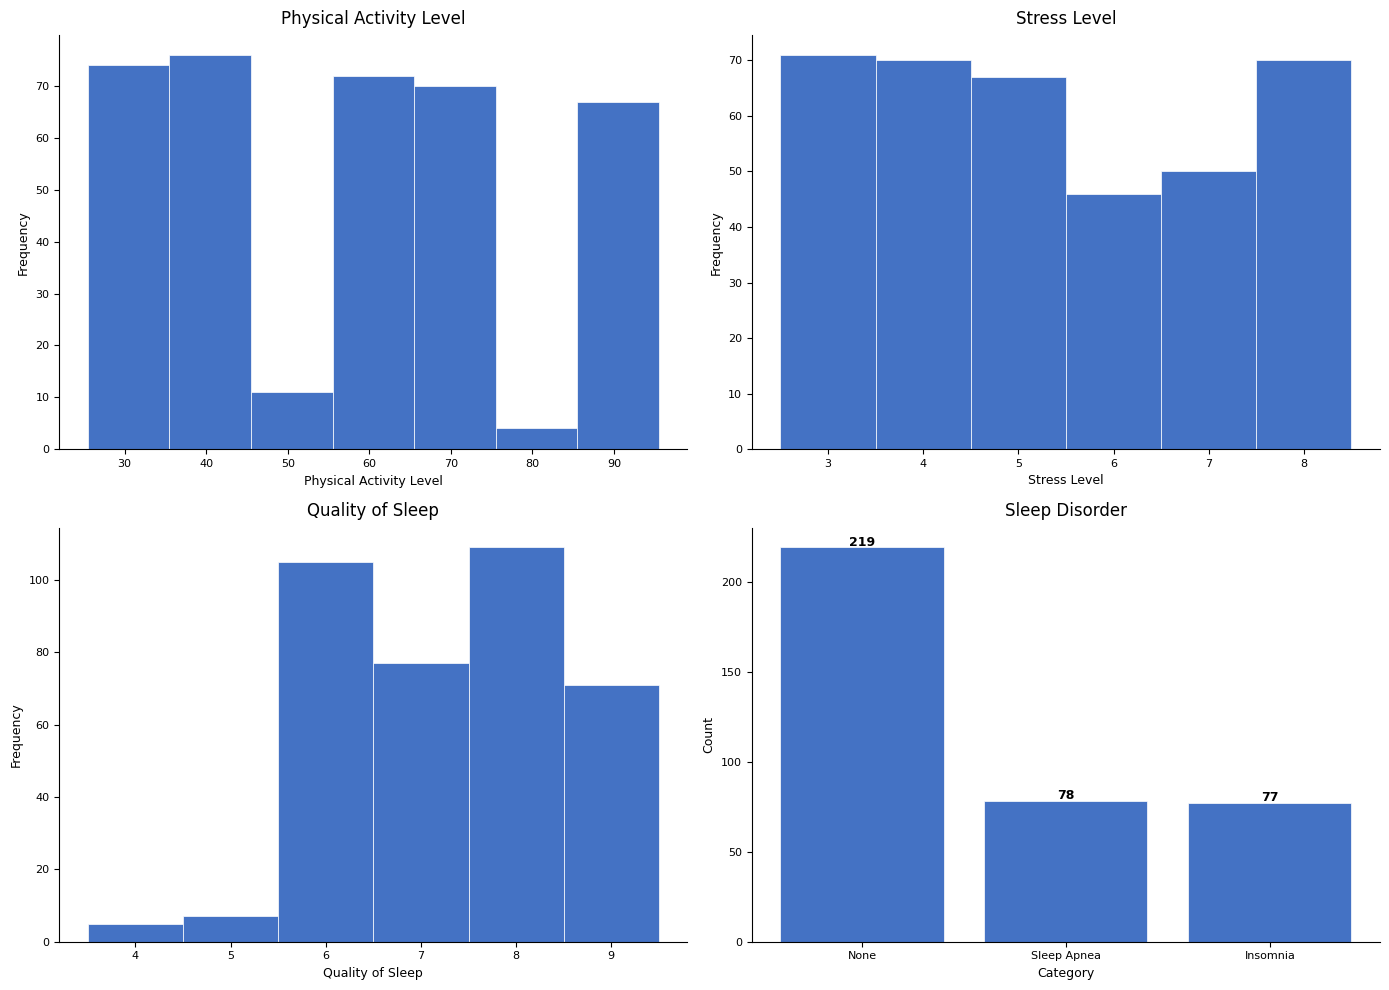

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('white')

# Physical Activity Level
axes[0, 0].hist(df['Physical Activity Level'],
             bins=arange(25.5, 100, 10),
             color='#4472C4', edgecolor='white', linewidth=0.5)
axes[0, 0].set_title('Physical Activity Level', fontsize=12, pad=8)
axes[0, 0].set_xlabel('Physical Activity Level', fontsize=9)
axes[0, 0].set_ylabel('Frequency', fontsize=9)
axes[0, 0].set_xticks(range(30, 100, 10))
axes[0, 0].tick_params(labelsize=8)
axes[0, 0].spines['top'].set_visible(False)
axes[0, 0].spines['right'].set_visible(False)

# Stress Level
axes[0, 1].hist(df['Stress Level'],
             bins=arange(2.5, 9, 1),
             color='#4472C4', edgecolor='white', linewidth=0.5)
axes[0, 1].set_title('Stress Level', fontsize=12, pad=8)
axes[0, 1].set_xlabel('Stress Level', fontsize=9)
axes[0, 1].set_ylabel('Frequency', fontsize=9)
axes[0, 1].set_xticks(range(3, 9, 1))
axes[0, 1].tick_params(labelsize=8)
axes[0, 1].spines['top'].set_visible(False)
axes[0, 1].spines['right'].set_visible(False)

# Quality of Sleep
unique_sq = sorted(df['Quality of Sleep'].unique())
bins_sq = [v - 0.5 for v in unique_sq] + [unique_sq[-1] + 0.5]

axes[1, 0].hist(df['Quality of Sleep'],
                bins=bins_sq,
                color='#4472C4', edgecolor='white', linewidth=0.5)
axes[1, 0].set_title('Quality of Sleep', fontsize=12, pad=8)
axes[1, 0].set_xlabel('Quality of Sleep', fontsize=9)
axes[1, 0].set_ylabel('Frequency', fontsize=9)
axes[1, 0].set_xticks(unique_sq)
axes[1, 0].tick_params(labelsize=8)
axes[1, 0].spines['top'].set_visible(False)
axes[1, 0].spines['right'].set_visible(False)

# Sleep Disorder
counts = df['Sleep Disorder'].value_counts()
bars = axes[1, 1].bar(counts.index, counts.values,
                      color='#4472C4', edgecolor='white', linewidth=0.5)
axes[1, 1].set_title('Sleep Disorder', fontsize=12, pad=8)
axes[1, 1].set_xlabel('Category', fontsize=9)
axes[1, 1].set_ylabel('Count', fontsize=9)
axes[1, 1].tick_params(labelsize=8)
axes[1, 1].spines['top'].set_visible(False)
axes[1, 1].spines['right'].set_visible(False)

for bar, val in zip(bars, counts.values):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    str(val), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

### Korelasi Antar Fitur Numerik

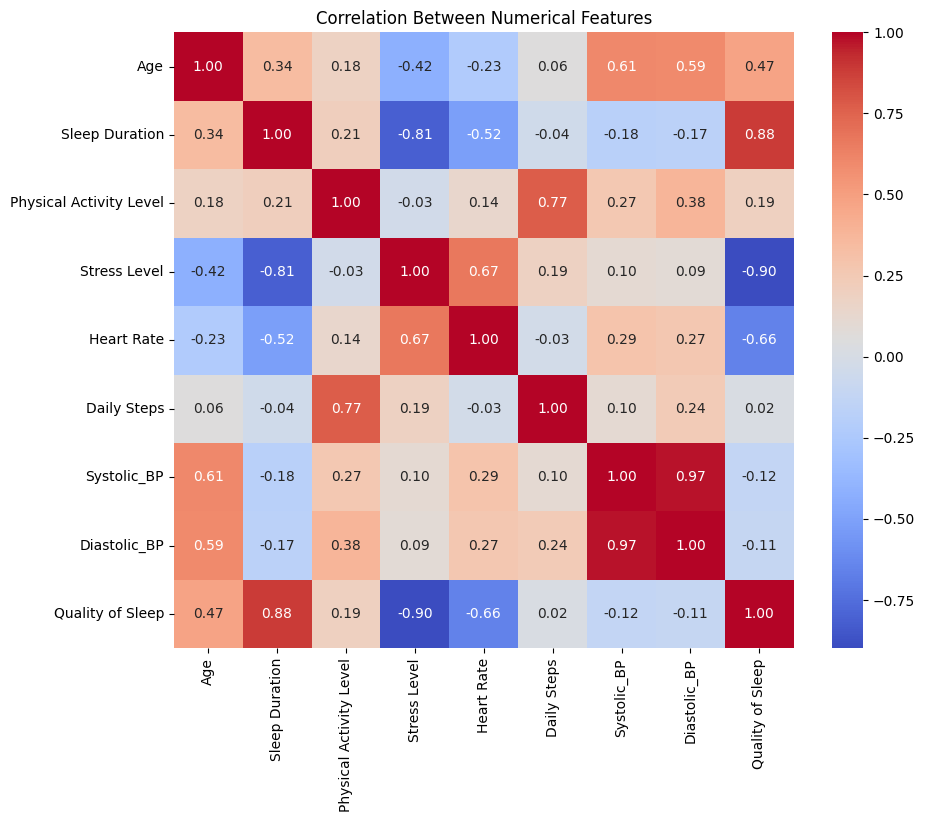

In [ ]:
num_cols = ["Age", "Sleep Duration", "Physical Activity Level",
            "Stress Level", "Heart Rate", "Daily Steps",
            "Systolic_BP", "Diastolic_BP"]

plt.figure(figsize=(10,8))
sns.heatmap(df_clean[num_cols + ["Quality of Sleep"]].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Between Numerical Features")
plt.show()

### Hubungan Fitur Katerogikal dengan Sleep Quality

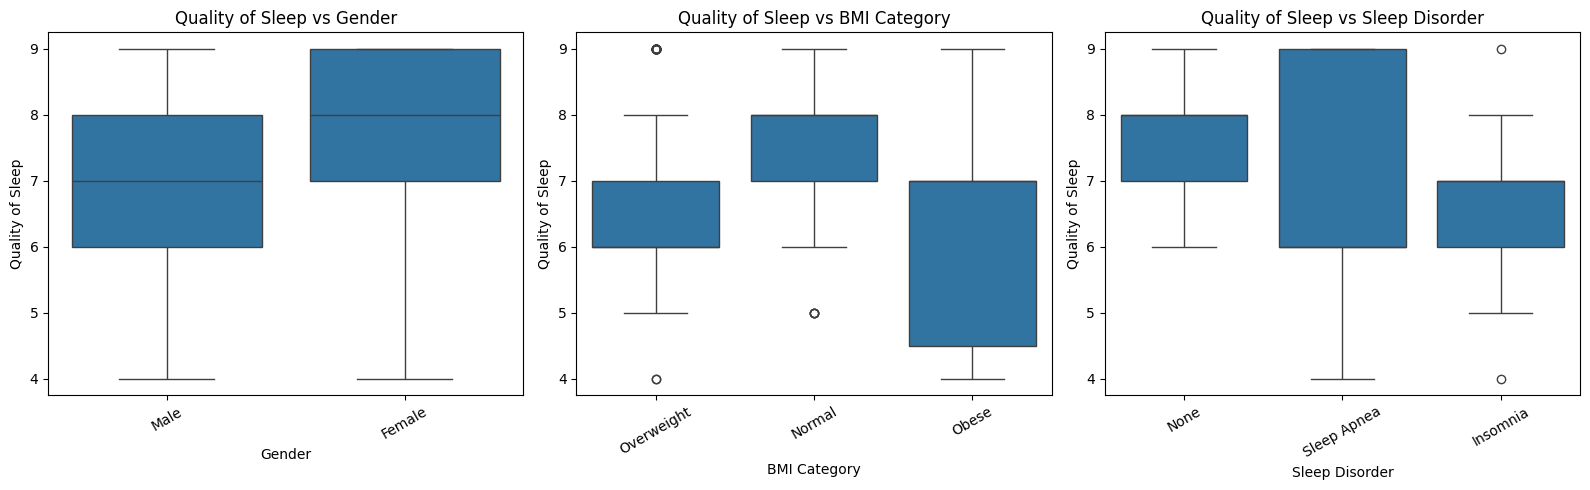

In [ ]:
cat_cols = ["Gender", "BMI Category", "Sleep Disorder"]

fig, axes = plt.subplots(1, len(cat_cols), figsize=(16,5))
for i, col in enumerate(cat_cols):
    sns.boxplot(x=col, y="Quality of Sleep", data=df_clean, ax=axes[i])
    axes[i].set_title(f"Quality of Sleep vs {col}")
    axes[i].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

### Distribusi Profesi

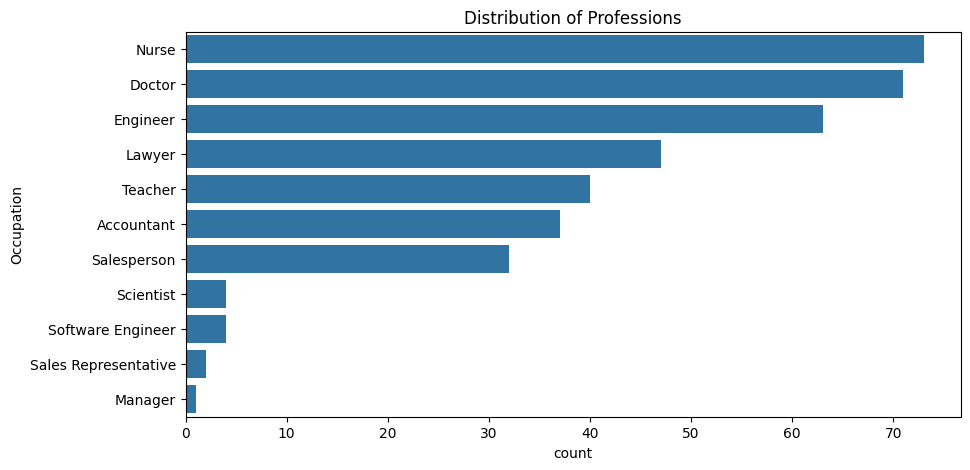

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(y="Occupation", data=df_clean, order=df_clean["Occupation"].value_counts().index)
plt.title("Distribution of Professions")
plt.show()

## **Pemodelan**

### Encoding Fitur Kategorikal

In [ ]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = ["Gender", "Occupation", "BMI Category", "Sleep Disorder"]
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    encoders[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

df_clean

Gender: {'Female': np.int64(0), 'Male': np.int64(1)}
Occupation: {'Accountant': np.int64(0), 'Doctor': np.int64(1), 'Engineer': np.int64(2), 'Lawyer': np.int64(3), 'Manager': np.int64(4), 'Nurse': np.int64(5), 'Sales Representative': np.int64(6), 'Salesperson': np.int64(7), 'Scientist': np.int64(8), 'Software Engineer': np.int64(9), 'Teacher': np.int64(10)}
BMI Category: {'Normal': np.int64(0), 'Obese': np.int64(1), 'Overweight': np.int64(2)}
Sleep Disorder: {'Insomnia': np.int64(0), 'None': np.int64(1), 'Sleep Apnea': np.int64(2)}


,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic_BP,Diastolic_BP
0,1,27,9,6.1,6,42,6,2,77,4200,1,126,83
1,1,28,1,6.2,6,60,8,0,75,10000,1,125,80
2,1,28,1,6.2,6,60,8,0,75,10000,1,125,80
3,1,28,6,5.9,4,30,8,1,85,3000,2,140,90
4,1,28,6,5.9,4,30,8,1,85,3000,2,140,90
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,0,59,5,8.1,9,75,3,2,68,7000,2,140,95
370,0,59,5,8.0,9,75,3,2,68,7000,2,140,95
371,0,59,5,8.1,9,75,3,2,68,7000,2,140,95
372,0,59,5,8.1,9,75,3,2,68,7000,2,140,95


### Pengelompokan Kualitas Tidur Berdasarkan SQS (Single-Item Sleep Quality Scale)

Karena skala 1-10 pada dataset tidak lengkap (hanya tersedia nilai 4-9), nilai Quality of Sleep dikelompokkan ke dalam kategori berdasarkan Single-Item Sleep Quality Scale (SQS):


In [ ]:
def map_sleep_quality(score):
    if score <= 6:
        return "Fair"
    else:
        return "Good"

df_clean["Sleep Quality Category"] = df_clean["Quality of Sleep"].apply(map_sleep_quality)

print("Distribusi kategori kualitas tidur (SQS):")
print(df_clean["Sleep Quality Category"].value_counts())
print()
print("Detail per nilai asli:")
print(df_clean.groupby("Quality of Sleep")["Sleep Quality Category"].first())

Distribusi kategori kualitas tidur (SQS):
Sleep Quality Category
Good    257
Fair    117
Name: count, dtype: int64

Detail per nilai asli:
Quality of Sleep
4    Fair
5    Fair
6    Fair
7    Good
8    Good
9    Good
Name: Sleep Quality Category, dtype: object


### Split Data Train dan Test

In [ ]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=["Quality of Sleep", "Sleep Quality Category"])
y = df_clean["Sleep Quality Category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Jumlah data train:", X_train.shape[0])
print("Jumlah data test :", X_test.shape[0])
print("\nDistribusi kelas di y_train:")
print(y_train.value_counts())
print("\nDistribusi kelas di y_test:")
print(y_test.value_counts())

Jumlah data train: 299
Jumlah data test : 75

Distribusi kelas di y_train:
Sleep Quality Category
Good    205
Fair     94
Name: count, dtype: int64

Distribusi kelas di y_test:
Sleep Quality Category
Good    52
Fair    23
Name: count, dtype: int64


### Menggunakan SMOTE untuk mengatasi kolom Quality of Sleep yang tidak seimbang

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, k_neighbors=3)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Sebelum SMOTE:")
print(y_train.value_counts().sort_index())
print("\nSetelah SMOTE:")
print(y_train_resampled.value_counts().sort_index())
print("\nJumlah data train setelah SMOTE:", X_train_resampled.shape[0])

Sebelum SMOTE:
Sleep Quality Category
Fair     94
Good    205
Name: count, dtype: int64

Setelah SMOTE:
Sleep Quality Category
Fair    205
Good    205
Name: count, dtype: int64

Jumlah data train setelah SMOTE: 410


### Standarisasi Fitur Numerik (StandardScaler)

In [ ]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ["Age", "Sleep Duration", "Physical Activity Level",
                "Stress Level", "Heart Rate", "Daily Steps",
                "Systolic_BP", "Diastolic_BP"]

scaler = StandardScaler()

X_train_scaled = X_train_resampled.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train_resampled[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])
X_train_scaled.head()

,Gender,Age,Occupation,Sleep Duration,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic_BP,Diastolic_BP
0,1,0.185548,7,-0.458623,-0.514322,0.578777,2,0.224639,-0.431504,0,0.123740,-0.000806
1,0,2.063931,5,1.412735,0.860631,-1.618431,2,-0.747412,0.145527,1,1.455330,1.650933
2,1,0.185548,2,1.163220,1.548108,-0.519827,0,-0.261387,0.722559,1,0.123740,-0.000806
3,0,-0.518846,0,0.414677,0.173155,-1.069129,0,-0.747412,0.145527,1,-1.873644,-1.652545
4,0,1.007340,5,-1.082409,1.548108,1.128078,2,0.953677,1.876622,2,1.455330,1.650933


### Decision Tree

Accuracy: 0.9733333333333334

Classification Report:
              precision    recall  f1-score   support

        Fair       1.00      0.91      0.95        23
        Good       0.96      1.00      0.98        52

    accuracy                           0.97        75
   macro avg       0.98      0.96      0.97        75
weighted avg       0.97      0.97      0.97        75



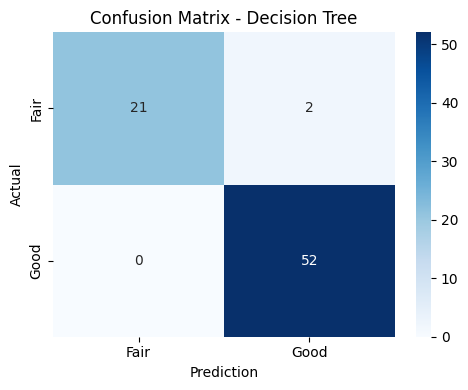

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train_resampled)

y_pred_dt = dt_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

cm = confusion_matrix(y_test, y_pred_dt, labels=["Fair", "Good"])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fair", "Good"], yticklabels=["Fair", "Good"])
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### Random Forest

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

        Fair       1.00      1.00      1.00        23
        Good       1.00      1.00      1.00        52

    accuracy                           1.00        75
   macro avg       1.00      1.00      1.00        75
weighted avg       1.00      1.00      1.00        75



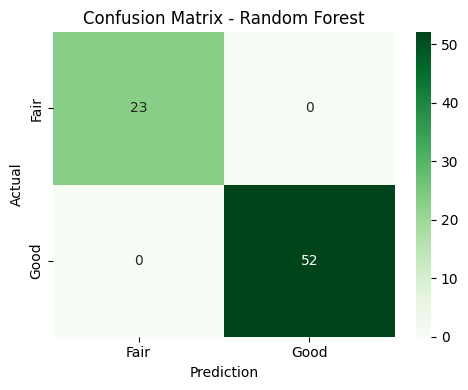

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train_scaled, y_train_resampled)

y_pred_rf = rf_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf, labels=["Fair", "Good"])
plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Fair", "Good"], yticklabels=["Fair", "Good"])
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### Support Vector Machine (SVM)

Accuracy: 0.9866666666666667

Classification Report:
              precision    recall  f1-score   support

        Fair       0.96      1.00      0.98        23
        Good       1.00      0.98      0.99        52

    accuracy                           0.99        75
   macro avg       0.98      0.99      0.98        75
weighted avg       0.99      0.99      0.99        75



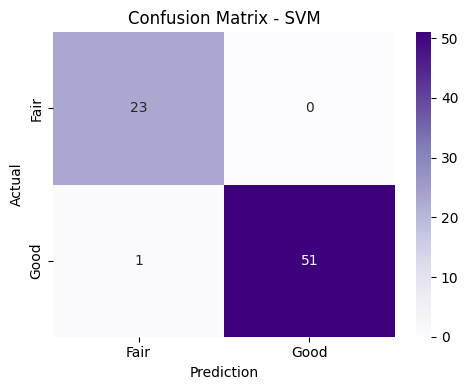

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(kernel="rbf", random_state=42)
svm_model.fit(X_train_scaled, y_train_resampled)

y_pred_svm = svm_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

cm_svm = confusion_matrix(y_test, y_pred_svm, labels=["Fair", "Good"])
plt.figure(figsize=(5, 4))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Purples",
            xticklabels=["Fair", "Good"], yticklabels=["Fair", "Good"])
plt.title("Confusion Matrix - SVM")
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### Gradient Boosting

Accuracy: 0.9733333333333334

Classification Report:
              precision    recall  f1-score   support

        Fair       1.00      0.91      0.95        23
        Good       0.96      1.00      0.98        52

    accuracy                           0.97        75
   macro avg       0.98      0.96      0.97        75
weighted avg       0.97      0.97      0.97        75



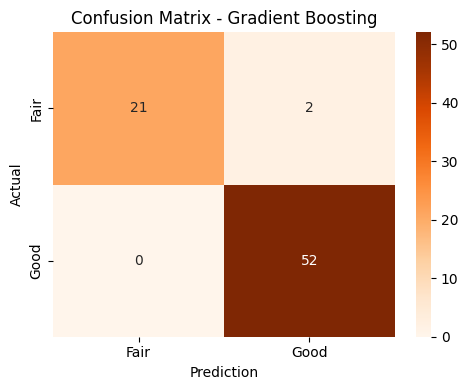

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train_scaled, y_train_resampled)

y_pred_gb = gb_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

cm_gb = confusion_matrix(y_test, y_pred_gb, labels=["Fair", "Good"])
plt.figure(figsize=(5, 4))
sns.heatmap(cm_gb, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["Fair", "Good"], yticklabels=["Fair", "Good"])
plt.title("Confusion Matrix - Gradient Boosting")
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# **Evaluation Testing Comparison**

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

results = {
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "SVM": y_pred_svm,
    "Gradient Boosting": y_pred_gb,
}

rows = []
for model_name, y_pred in results.items():
    report = classification_report(y_test, y_pred,
                                   output_dict=True,
                                   zero_division=0)
    for cls in ["Fair", "Good"]:
        rows.append({
            "Model": model_name,
            "Class": cls,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": round(report[cls]["precision"], 3),
            "Recall": round(report[cls]["recall"], 3),
            "F1-Score": round(report[cls]["f1-score"], 3),
        })

comparison_df = pd.DataFrame(rows)
comparison_df

,Model,Class,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,Fair,0.973333,1.000,0.913,0.955
1,Decision Tree,Good,0.973333,0.963,1.000,0.981
2,Random Forest,Fair,1.000000,1.000,1.000,1.000
3,Random Forest,Good,1.000000,1.000,1.000,1.000
4,SVM,Fair,0.986667,0.958,1.000,0.979
5,SVM,Good,0.986667,1.000,0.981,0.990
6,Gradient Boosting,Fair,0.973333,1.000,0.913,0.955
7,Gradient Boosting,Good,0.973333,0.963,1.000,0.981
